<a href="https://colab.research.google.com/github/thvsbg/PyTorch/blob/main/02_Pytorch_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sklearn

In [ ]:
from sklearn.datasets import make_circles
n_samples=1000
X,y=make_circles(1000,noise=0.03,random_state=42)
print(len(X),len(y))

1000 1000


In [ ]:
print(X[:10])
print("y")
print(y[:10])

[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]
 [-0.47964637  0.67643477]
 [-0.01364836  0.80334872]
 [ 0.77151327  0.14775959]
 [-0.16932234 -0.79345575]
 [-0.1214858   1.02150905]]
y
[1 1 1 1 0 1 1 1 1 0]


In [ ]:
import pandas as pd
circles=pd.DataFrame({"X1":X[:,0],
                      "X2":X[:,1],
                      "label":y})
print(circles)

           X1        X2  label
0    0.754246  0.231481      1
1   -0.756159  0.153259      1
2   -0.815392  0.173282      1
3   -0.393731  0.692883      1
4    0.442208 -0.896723      0
..        ...       ...    ...
995  0.244054  0.944125      0
996 -0.978655 -0.272373      0
997 -0.136900 -0.810012      1
998  0.670362 -0.767502      0
999  0.281057  0.963824      0

[1000 rows x 3 columns]


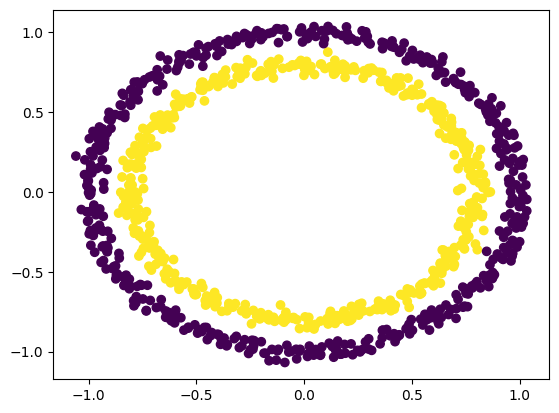

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(circles["X1"],circles["X2"],c=y)
plt.show()

In [ ]:
X.shape

(1000, 2)

In [ ]:
import torch

In [ ]:
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

In [ ]:
##train and test sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
##Building a model
from torch import nn

##device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1=nn.Linear(in_features=2,out_features=5)
    self.layer_2=nn.Linear(in_features=5,out_features=1)

  def forward(self,x):
    return self.layer_2(self.layer_1(x))


model_0=CircleModelV0().to(device)
model_0


CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

Try to recreate the model using nn.Sequential.

In [ ]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.6776, -0.2908],
                      [-0.5111, -0.6886],
                      [ 0.3874,  0.5473],
                      [ 0.6547,  0.4559],
                      [ 0.2777, -0.3237]])),
             ('layer_1.bias',
              tensor([-0.3250, -0.3772, -0.0573, -0.2547, -0.0432])),
             ('layer_2.weight',
              tensor([[ 0.0852,  0.2489, -0.0980,  0.1213,  0.0121]])),
             ('layer_2.bias', tensor([-0.1256]))])

In [ ]:
## loss function and optimizer

loss_fn=nn.BCEWithLogitsLoss() ##built-in sigmoid activation function
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.1)


In [ ]:
##defining accuracy
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=(correct/len(y_pred))*100
  return acc

In [ ]:
## logits to prediction probability to labels

with torch.inference_mode():
  y_logit=model_0(X_test[:5])
  y_pred=torch.round(torch.sigmoid(y_logit))

##check for equality
print(y_test[:5])
print(y_pred.squeeze(1))
print(torch.eq(y_test[:5],y_pred.squeeze(1)))



tensor([1., 0., 1., 0., 1.])
tensor([0., 0., 0., 0., 0.])
tensor([False,  True, False,  True, False])


In [ ]:
##building train and test loops
torch.manual_seed(42)
epochs=100

for epoch in range(epochs):
  model_0.train()
  y_logits=model_0(X_train)
  y_preds=torch.round(torch.sigmoid(y_logits))

